In [1]:
# !pip install scikit-image

In [2]:
import numpy as np
import pandas as pd
import scipy.io as sio
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops

def extract_melt_pool_features(mat_filepath, start_idx, end_idx, track_id):
    # 1. Load the MATLAB file (adjust if it's an HDF5-based .mat v7.3 file)
    mat_data = sio.loadmat(mat_filepath)
    video = mat_data['temperature_data']  # Shape should be [Frames, 400, 400]
    
    # 2. Slice the 400 validated frames
    frames = video[start_idx:end_idx]
    
    features_list = []
    
    for i, frame in enumerate(frames):
        # Physical x-position (20.1mm to 99.9mm)
        current_x_mm = 20.1 + (i * 0.2)
        
        # 3. Handle dead pixels (NaNs) and find max temperature
        frame_clean = np.nan_to_num(frame, nan=0.0)
        peak_temp = np.max(frame_clean)
        mean_temp = np.mean(frame_clean[frame_clean > 0]) # mean of non-zero
        
        # 4. Segment the melt pool
        # Option A: Absolute Threshold (e.g., melting point of 316L SS ~ 1370-1400 °C)
        # Option B: Otsu's method (Adaptive) - Using Otsu here as it handles intensity shifts well
        try:
            thresh = threshold_otsu(frame_clean[frame_clean > 0]) 
            binary_mask = frame_clean > thresh
        except ValueError:
            # Fallback if frame is empty/corrupt
            binary_mask = frame_clean > 1000 
            
        # 5. Extract Geometric properties of the melt pool
        labeled_mask = label(binary_mask)
        props = regionprops(labeled_mask, intensity_image=frame_clean)
        
        # Assume the largest contiguous region is the melt pool
        if props:
            melt_pool = max(props, key=lambda p: p.area)
            area_pixels = melt_pool.area
            centroid_y, centroid_x = melt_pool.centroid
            major_axis = melt_pool.axis_major_length
            minor_axis = melt_pool.axis_minor_length
        else:
            area_pixels, centroid_y, centroid_x, major_axis, minor_axis = 0, np.nan, np.nan, 0, 0
            
        # Append to our frame record
        features_list.append({
            'track_id': track_id,
            'frame_index': start_idx + i,
            'x_position_mm': current_x_mm,
            'peak_temp': peak_temp,
            'mean_temp': mean_temp,
            'mp_area_px': area_pixels,
            'mp_centroid_x': centroid_x,
            'mp_centroid_y': centroid_y,
            'mp_length': major_axis,
            'mp_width': minor_axis
        })
        
    return pd.DataFrame(features_list)

In [4]:
# --- How to use it with your JSON ---
df_track8 = extract_melt_pool_features("C:/Users/adity/Documents/Coursework/Projects/nsf-fmrg-data-challenge/data/raw/thermal/Thermal_8.mat", 337, 737, 8)
df_track8.head()

,track_id,frame_index,x_position_mm,peak_temp,mean_temp,mp_area_px,mp_centroid_x,mp_centroid_y,mp_length,mp_width
0,8,337,20.1,2738,1198.670735,3245.0,252.370416,224.947612,66.054862,62.818574
1,8,338,20.3,2727,1175.388495,3327.0,251.885182,224.671175,66.567997,63.803098
2,8,339,20.5,2713,1196.561692,3235.0,252.259351,224.924884,65.235197,63.279279
3,8,340,20.7,2703,1191.768436,3228.0,252.396530,224.736679,65.267545,63.244511
4,8,341,20.9,2683,1199.894918,3322.0,252.838651,225.096026,65.403024,64.754598


In [ ]:
import os

# Your track IDs and their start/end indices from the JSON
track_metadata = {
    8:  {'start': 337, 'end': 737, 'path': r"C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\data\raw\thermal\Thermal_8.mat"},
    10: {'start': 341, 'end': 741, 'path': r"C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\data\raw\thermal\Thermal_10.mat"},
    14: {'start': 385, 'end': 785, 'path': r"C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\data\raw\thermal\Thermal_14.mat"},
    21: {'start': 329, 'end': 729, 'path': r"C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\data\raw\thermal\Thermal_21.mat"}
}

all_tracks_df = pd.DataFrame()

print("Extracting features for all tracks...")
for track_id, info in track_metadata.items():
    print(f"Processing Track {track_id}...")
    df_track = extract_melt_pool_features(info['path'], info['start'], info['end'], track_id)
    all_tracks_df = pd.concat([all_tracks_df, df_track], ignore_index=True)

# Save the unified dataset
output_dir = r"C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data"
os.makedirs(output_dir, exist_ok=True)

save_path = os.path.join(output_dir, "phase1_thermal_features.csv")
all_tracks_df.to_csv(save_path, index=False)

print(f"Success! Extracted {len(all_tracks_df)} total frames. Saved to {save_path}")

Extracting features for all tracks...
Processing Track 8...
Processing Track 10...
Processing Track 14...
Processing Track 21...
Success! Extracted 1600 total frames. Saved to C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\data\processed\phase1_thermal_features.csv


In [3]:
import os
import glob
import numpy as np
import pandas as pd
from skimage.io import imread
from skimage.feature.texture import graycomatrix, graycoprops

def extract_sem_substrate_features(track_id, sem_dir, num_tiles, tile_fov_mm):
    """
    Extracts substrate roughness/texture features from SEM tiles, 
    accounting for the reverse spatial numbering.
    """
    # Find all tiles for this track and sort them (Tile01, Tile02...)
    search_pattern = os.path.join(sem_dir, f"*Track{track_id}*.tif") # Adjust pattern as needed
    tile_files = sorted(glob.glob(search_pattern))
    
    if len(tile_files) == 0:
        print(f"No SEM files found for Track {track_id}")
        return pd.DataFrame()
        
    features_list = []
    
    # Tile 01 is at the 100mm mark. 
    # If FOV is, say, 5mm, then Tile 01 covers roughly 95mm to 100mm.
    current_x_start = 100.0 
    
    for i, file_path in enumerate(tile_files):
        # 1. Calculate physical X-range for this specific tile (moving backwards)
        current_x_end = current_x_start - tile_fov_mm
        midpoint_x = (current_x_start + current_x_end) / 2.0
        
        # 2. Load the image
        img = imread(file_path, as_gray=True)
        
        # 3. Mask out the processed track region!
        # Assuming the track runs straight down the middle horizontally or vertically.
        # Example: If track is horizontal, mask out the middle 30% of rows.
        h, w = img.shape
        margin = int(h * 0.35) 
        
        # Extract just the top and bottom untouched substrate
        top_substrate = img[0:margin, :]
        bottom_substrate = img[h-margin:h, :]
        substrate_pixels = np.concatenate((top_substrate.flatten(), bottom_substrate.flatten()))
        
        # 4. Calculate Features (e.g., simple variance for roughness)
        # (For advanced GLCM contrast, you'd apply it to the 2D patches instead of flattened arrays)
        local_variance = np.var(substrate_pixels)
        local_mean = np.mean(substrate_pixels)
        
        features_list.append({
            'track_id': track_id,
            'sem_tile_index': i + 1,
            'x_start_mm': current_x_end, # Start is the lower number
            'x_end_mm': current_x_start, # End is the higher number
            'x_midpoint_mm': midpoint_x,
            'substrate_variance': local_variance,
            'substrate_mean_intensity': local_mean
        })
        
        # Update starting position for the next tile (it will overlap slightly in reality, 
        # but this represents the pure step size)
        current_x_start = current_x_end
        
    return pd.DataFrame(features_list)

In [ ]:
import os
import glob

# Adjust this to your actual base path
sem_base_dir = r"C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\data\raw\sem"
tracks = [8, 10, 14, 21]

print("--- SEM Tile Counts ---")
for track_id in tracks:
    plain_dir = os.path.join(sem_base_dir, f"SEM_{track_id}", "PlainImages")
    search_pattern = os.path.join(plain_dir, "Plain_SEM_*.tif")
    
    # Find and sort the files
    tile_files = sorted(glob.glob(search_pattern))
    print(f"Track {track_id}: {len(tile_files)} tiles found.")

--- SEM Tile Counts ---
Track 8: 13 tiles found.
Track 10: 13 tiles found.
Track 14: 1 tiles found.
Track 21: 14 tiles found.


In [6]:
import os
import glob

# Adjust this to your actual base path
sem_base_dir = r"C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\data\raw\sem"
tracks = [8, 10, 14, 21]

print("--- SEM Tile Counts ---")
for track_id in tracks:
    plain_dir = os.path.join(sem_base_dir, f"SEM_{track_id}", "PlainImages")
    search_pattern = os.path.join(plain_dir, "Plain_SEM_*.tif")
    
    # Find and sort the files
    tile_files = sorted(glob.glob(search_pattern))
    print(f"Track {track_id}: {len(tile_files)} tiles found.")

--- SEM Tile Counts ---
Track 8: 13 tiles found.
Track 10: 13 tiles found.
Track 14: 13 tiles found.
Track 21: 14 tiles found.


In [7]:
import os
import glob
import numpy as np
import pandas as pd
from skimage.io import imread

def extract_sem_substrate_features(track_id, sem_base_dir):
    # 1. Locate the files
    plain_dir = os.path.join(sem_base_dir, f"SEM_{track_id}", "PlainImages")
    search_pattern = os.path.join(plain_dir, "Plain_SEM_*.tif")
    tile_files = sorted(glob.glob(search_pattern))
    
    num_tiles = len(tile_files)
    if num_tiles == 0:
        print(f"Track {track_id}: No SEM files found. Skipping.")
        return pd.DataFrame()
    elif num_tiles < 5:
        print(f"Track {track_id}: WARNING! Only {num_tiles} tiles found. Data may be incomplete.")
        
    print(f"Track {track_id}: Processing {num_tiles} tiles...")
    
    # 2. Dynamic Physical Math
    # The SEM scans the full 100mm plate. 
    # Tile 01 starts at 100mm and moves backwards.
    step_size_mm = 100.0 / num_tiles 
    current_x_start = 100.0 
    
    features_list = []
    
    for i, file_path in enumerate(tile_files):
        current_x_end = current_x_start - step_size_mm
        midpoint_x = (current_x_start + current_x_end) / 2.0
        
        # Load the image
        img = imread(file_path, as_gray=True)
        
        # 3. Mask out the processed track
        # The laser track is usually down the center. We will take the top 30% 
        # and bottom 30% of the image to ensure we only look at raw substrate.
        h, w = img.shape
        margin = int(h * 0.30) 
        
        top_substrate = img[0:margin, :]
        bottom_substrate = img[h-margin:h, :]
        
        # Flatten into one 1D array of substrate pixels
        substrate_pixels = np.concatenate((top_substrate.flatten(), bottom_substrate.flatten()))
        
        # 4. Calculate Substrate Condition (Roughness / Variance)
        # Using variance of pixel intensities as a proxy for surface roughness
        local_variance = np.var(substrate_pixels)
        local_mean = np.mean(substrate_pixels)
        
        features_list.append({
            'track_id': track_id,
            'sem_tile_index': i + 1,
            'x_start_mm': current_x_end, # Lower boundary
            'x_end_mm': current_x_start, # Upper boundary
            'x_midpoint_mm': midpoint_x,
            'substrate_roughness_variance': local_variance,
            'substrate_mean_intensity': local_mean
        })
        
        # Move our spatial window for the next tile
        current_x_start = current_x_end
        
    return pd.DataFrame(features_list)

# --- Execute for all tracks ---
sem_base_dir = r"C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\data\raw\sem"
tracks = [8, 10, 14, 21]

all_sem_features = pd.DataFrame()

for t_id in tracks:
    df_track_sem = extract_sem_substrate_features(t_id, sem_base_dir)
    all_sem_features = pd.concat([all_sem_features, df_track_sem], ignore_index=True)

# Save the dataset
output_path = r"C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\phase1_sem_features.csv"
all_sem_features.to_csv(output_path, index=False)
print(f"\nSuccess! SEM features saved to {output_path}")
display(all_sem_features.head())

Track 8: Processing 13 tiles...
Track 10: Processing 13 tiles...
Track 14: Processing 13 tiles...
Track 21: Processing 14 tiles...

Success! SEM features saved to C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data\phase1_sem_features.csv


,track_id,sem_tile_index,x_start_mm,x_end_mm,x_midpoint_mm,substrate_roughness_variance,substrate_mean_intensity
0,8,1,92.307692,100.000000,96.153846,1485.157672,117.629719
1,8,2,84.615385,92.307692,88.461538,2508.506689,114.784780
2,8,3,76.923077,84.615385,80.769231,3126.117083,130.914315
3,8,4,69.230769,76.923077,73.076923,3348.100944,127.158010
4,8,5,61.538462,69.230769,65.384615,1209.911050,102.126979


### Unified Dataset Merge

In [10]:
import pandas as pd
import os

# 1. Load the two datasets
processed_dir = r"C:\Users\adity\Documents\Coursework\Projects\nsf-fmrg-data-challenge\processed_data"
thermal_path = os.path.join(processed_dir, "phase1_thermal_features.csv")
sem_path = os.path.join(processed_dir, "phase1_sem_features.csv")

thermal_df = pd.read_csv(thermal_path)
sem_df = pd.read_csv(sem_path)

# 2. CRITICAL STEP: Sort purely by the spatial X-axis first!
thermal_df = thermal_df.sort_values(by='x_position_mm').reset_index(drop=True)
sem_df = sem_df.sort_values(by='x_midpoint_mm').reset_index(drop=True)

# 3. Perform the As-Of Merge
unified_df = pd.merge_asof(
    left=thermal_df, 
    right=sem_df,
    left_on='x_position_mm',
    right_on='x_midpoint_mm',
    by='track_id',
    direction='nearest'
)

# Optional: Re-sort by track_id at the very end so it's clean and easy for humans to read
unified_df = unified_df.sort_values(by=['track_id', 'x_position_mm']).reset_index(drop=True)
unified_df = unified_df.drop(columns=['x_midpoint_mm'])

# Clean up redundant columns safely (ignores if already dropped)
unified_df = unified_df.drop(columns=['x_midpoint_mm'], errors='ignore')

# 4. Save the Rosetta Stone!
unified_out_path = os.path.join(processed_dir, "phase1_unified_master.csv")
unified_df.to_csv(unified_out_path, index=False)

print(f"Merge Complete! Unified dataset shape: {unified_df.shape}")
display(unified_df.head(10))

Merge Complete! Unified dataset shape: (1600, 15)


,track_id,frame_index,x_position_mm,peak_temp,mean_temp,mp_area_px,mp_centroid_x,mp_centroid_y,mp_length,mp_width,sem_tile_index,x_start_mm,x_end_mm,substrate_roughness_variance,substrate_mean_intensity
0,8,337,20.1,2738,1198.670735,3245.0,252.370416,224.947612,66.054862,62.818574,11,15.384615,23.076923,2600.496795,121.916595
1,8,338,20.3,2727,1175.388495,3327.0,251.885182,224.671175,66.567997,63.803098,11,15.384615,23.076923,2600.496795,121.916595
2,8,339,20.5,2713,1196.561692,3235.0,252.259351,224.924884,65.235197,63.279279,11,15.384615,23.076923,2600.496795,121.916595
3,8,340,20.7,2703,1191.768436,3228.0,252.396530,224.736679,65.267545,63.244511,11,15.384615,23.076923,2600.496795,121.916595
4,8,341,20.9,2683,1199.894918,3322.0,252.838651,225.096026,65.403024,64.754598,11,15.384615,23.076923,2600.496795,121.916595
5,8,342,21.1,2786,1220.930700,3407.0,252.251247,224.911946,66.591837,65.332581,11,15.384615,23.076923,2600.496795,121.916595
6,8,343,21.3,2695,1188.607004,3576.0,252.626957,224.687360,68.442350,66.785423,11,15.384615,23.076923,2600.496795,121.916595
7,8,344,21.5,2736,1209.100001,3381.0,252.539190,225.016859,66.548685,64.904968,11,15.384615,23.076923,2600.496795,121.916595
8,8,345,21.7,2729,1208.911968,3425.0,251.993285,225.204088,67.240173,65.018936,11,15.384615,23.076923,2600.496795,121.916595
9,8,346,21.9,2765,1197.627810,3311.0,252.238297,225.326487,66.168483,63.909147,11,15.384615,23.076923,2600.496795,121.916595


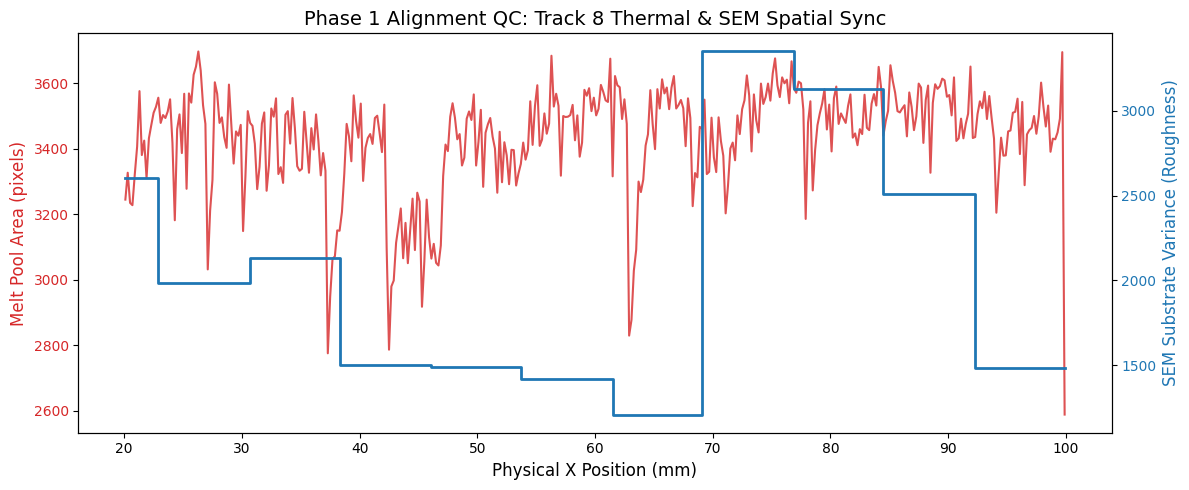

In [11]:
import matplotlib.pyplot as plt

# Filter just Track 8 for the demo
track_8 = unified_df[unified_df['track_id'] == 8]

fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot 1: Thermal Melt Pool Area (Left Y-Axis)
color1 = 'tab:red'
ax1.set_xlabel('Physical X Position (mm)', fontsize=12)
ax1.set_ylabel('Melt Pool Area (pixels)', color=color1, fontsize=12)
ax1.plot(track_8['x_position_mm'], track_8['mp_area_px'], color=color1, alpha=0.8, label='Melt Pool Area')
ax1.tick_params(axis='y', labelcolor=color1)

# Create a twin axis sharing the same X-axis
ax2 = ax1.twinx()  

# Plot 2: SEM Substrate Roughness (Right Y-Axis)
color2 = 'tab:blue'
ax2.set_ylabel('SEM Substrate Variance (Roughness)', color=color2, fontsize=12)
# Using a step plot since SEM data is binned/constant across tiles
ax2.step(track_8['x_position_mm'], track_8['substrate_roughness_variance'], color=color2, linewidth=2, label='Substrate Roughness')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Phase 1 Alignment QC: Track 8 Thermal & SEM Spatial Sync', fontsize=14)
fig.tight_layout()
plt.show()